# Lab 2: STM32 Activity Recognition with SVC and Python serial communication
### Customized to SVC from a lab within the course "Machine Learning at the Edge: A Practical Introduction from Arm" 

## Learning objectives

- Send serial data to Python for a shared information architecture
- Develop an activity recognition application using SVC with basic features
- Evaluate with and without feature extraction. Run and evaluate the performance

## Preparation

In [1]:
import serial.tools.list_ports
import sklearn
#import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, random

base_dir = os.getcwd()
samples_dir = os.path.join(base_dir, 'Samples')

Connect the MCU to the host PC

In [32]:
print('Com ports list:')
comPorts = list(serial.tools.list_ports.comports())
for comPort in comPorts:
    print(comPort)
chooseComPort = input('Please insert port number: ')
ser = serial.Serial('COM{}'.format(chooseComPort), 115200)

Com ports list:
COM6 - STMicroelectronics STLink Virtual COM Port (COM6)


Helper functions for data acquisition

In [13]:
def convert_to_list(value):
    value = value.replace("b' ", "")
    vals = value.split(", ")
    del vals[-1]
    results = list(map(int, vals))
    return results

def convert_list_to_df(lst):
    x = lst[0::3]
    y = lst[1::3]
    z = lst[2::3]
    df = pd.DataFrame({'X': x, 'Y': y, 'Z': z})
    return df

## Data Acquisition
Input the letter of the sample you want to acquire. The MCU will send the XYZ Accelerometer data as a timeseries of length 30. Run the cell -> Press a button on the MCU and move it until a LED turns off -> Insert the number 1 into the prompt to acquire the data or number 2 to exit -> Repeat

In [33]:
letter = input('Please insert letter to collect data: ')
stride = 30
f = os.path.join(samples_dir, 'letter_{}_stride_{}.csv'.format(letter, stride))
if os.path.exists(f):
    print('File exists and data will be appended...')
    xyz_df = pd.read_csv(f)
else:
    print('New sample, starting blank...')
    xyz_df = pd.DataFrame(columns=['X', 'Y', 'Z'])

while input('1 - acquire sample, 2 - exit: ') == '1':
    line = ser.readline()
    lineList = convert_to_list(str(line))
    new_df = convert_list_to_df(lineList)
    print('New data acquired:\n', new_df.describe())
    xyz_df = pd.concat([xyz_df, new_df], ignore_index=True)
    print('Total Data count:', int(xyz_df.shape[0]/stride))

print('Saving data to:', f)
print('Total data of sample {}:\n'.format(letter), xyz_df.describe())
xyz_df.to_csv(f, index=False)

File exists and data will be appended...
New data acquired:
                 X           Y            Z
count   30.000000   30.000000    30.000000
mean  -113.300000   54.833333   986.000000
std    151.064761  169.827313   103.137003
min   -486.000000 -419.000000   749.000000
25%   -197.750000    6.250000   945.000000
50%   -167.500000   47.000000   993.500000
75%    -20.250000   63.750000  1018.250000
max    289.000000  663.000000  1290.000000
Total Data count: 4
New data acquired:
                 X           Y            Z
count   30.000000   30.000000    30.000000
mean   -76.300000   13.200000  1038.900000
std    254.375659  225.933985    70.061722
min   -972.000000 -706.000000   876.000000
25%   -132.000000  -49.250000  1007.000000
50%   -105.000000  -16.500000  1034.500000
75%    -42.750000   57.250000  1068.500000
max    688.000000  577.000000  1197.000000
Total Data count: 5
Saving data to: c:\Users\cris_\Documents\UAA\Materias\TinyML\Jupyter\P1\Samples\letter_L_stride_30.csv
To

## Load data
Load all samples raw. Note that a single Accelerometer data batch will only contain 30 time steps. Thus to acquire single batches we must use an according "stride" of 30.

In [24]:
data_files = [file for file in os.listdir(samples_dir) if '.csv' in file]

stride = 30
data = []
labels = []
for idx, file in enumerate(data_files):
    df = pd.read_csv(os.path.join(samples_dir, file))
    x = df['X'].to_numpy()
    y = df['Y'].to_numpy()
    z = df['Z'].to_numpy()
    
    for i in range(int(df.shape[0]/stride)):
        base_idx = i * stride
        batch = np.array([x[base_idx:base_idx+stride], y[base_idx:base_idx+stride], z[base_idx:base_idx+stride]])
        batch = batch.reshape((3, stride))
        data.append(batch)
        labels.append(idx)
        
    print('Added {} data to the data list with label: {}'.format(file, idx))

Added letter_L_stride_30.csv data to the data list with label: 0
Added letter_o_stride_30.csv data to the data list with label: 1
Added letter_v_stride_30.csv data to the data list with label: 2


Let's plot one data sample.

<Figure size 640x480 with 0 Axes>

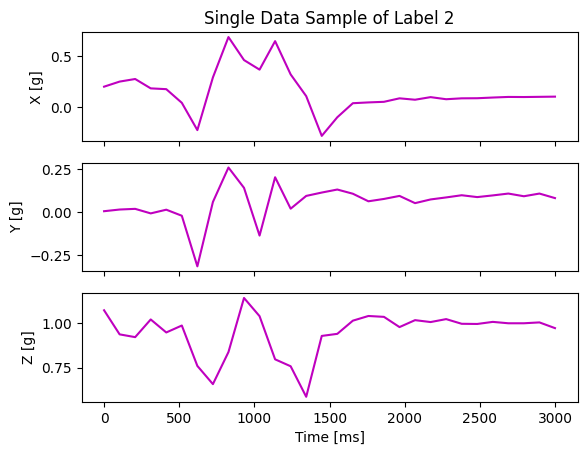

In [25]:
def plot_single_sample(data_sample, label='Not Specified'):
    plt.clf()
    scaling = 2**10 #The STM ADC is 10bit so scale to get [g]
    fig, axs = plt.subplots(3)
    t = np.linspace(0, data_sample.shape[1] * 100, data_sample.shape[1]) #Accelerometer sampled with 100ms
    axs[0].set_title(label='Single Data Sample of Label {}'.format(label))
    axs[0].plot(t, data_sample[0]/scaling, c='m')
    axs[0].set_ylabel('X [g]')
    plt.setp(axs[0].get_xticklabels(), visible=False)
    axs[1].plot(t, data_sample[1]/scaling, c='m')
    axs[1].set_ylabel('Y [g]')
    plt.setp(axs[1].get_xticklabels(), visible=False)
    axs[2].plot(t, data_sample[2]/scaling, c='m')
    axs[2].set_ylabel('Z [g]')
    plt.xlabel('Time [ms]')
    plt.show()
    
idx = random.randint(0, len(data)-1)
plot_single_sample(data_sample=data[idx], label=labels[idx])

In [26]:
print(np.array(data).shape)
print(np.array(labels).shape)
print(labels)

(23, 3, 30)
(23,)
[0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


# Model definition and training

In [27]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [28]:
#Train-Validation split (even it says test)

X_train, X_val, y_train, y_val = train_test_split(np.array(data), np.array(labels), test_size=0.1, random_state=42)
print("Train data shape is: ", X_train.shape)
print(X_train[0,:,:])
print("Validation data shape is: ", X_val.shape)
print(X_val[0,:,:])

print("Train labels shape is: ", y_train.shape)
print(y_train)
print("Validation labels shape is: ", y_val.shape)
print(y_val)



Train data shape is:  (20, 3, 30)
[[ -33   31  -77  -39  -64   15  158  307  302  236  -38 -150 -342 -384
  -290 -200  -40   24  297  130   82   94  -70  -89  -70  -87  -50  -23
   -57  -35]
 [ -35    0  -20   59  -20 -169 -122  124  238  423  353  339  -18 -177
  -129 -164 -111 -209 -106  -26   85  174  190  111    5  -29  -64  -31
   -11   -7]
 [1031 1035 1015 1000 1034 1069 1075 1042  939  971  821  923  905  944
  1070  959 1261 1161 1022 1014 1006  999 1066 1043  975 1035 1008 1021
  1033 1039]]
Validation data shape is:  (3, 3, 30)
[[ 192  112  241  157  143   97 -240 -252  464  633  375  465  327  169
   -96 -127   28  101   67   61   59  128  117  124  128  123  127  115
    89   98]
 [ -55  -56  -99 -128  -61  -75 -195 -263  141  151   56    0   46 -197
    65   93   15    2  -44   22  -14   39   21   43   37   70   38   16
    -2   18]
 [1041 1072  966  907 1017  975 1022  775  801 1004 1094 1301 1093  948
  1158 1170  991 1046 1064 1041 1082 1031 1009 1012  995 1039 1004 101

In [29]:
# SVC only accepts 2 dimension input, so reshape
x_flat_train = X_train.reshape(X_train.shape[0], -1)
print(x_flat_train.shape)

#Uncomment for a different SVM kernel classifier
clf_svc = SVC(kernel='linear', max_iter=200, probability=True)
#clf_svc = SVC(max_iter=20) #which is the default kernel?   // max_iter=-1 has no iter limit
clf_svc.fit(x_flat_train, y_train)

train_accuracy = clf_svc.score(x_flat_train, y_train)
print(f'Training Accuracy: {train_accuracy:.4f}')

(20, 90)
Training Accuracy: 1.0000


In [30]:
x_flat_val = X_val.reshape(X_val.shape[0], -1)
val_accuracy = clf_svc.score(x_flat_val, y_val)
print(f'Validation Accuracy: {val_accuracy:.4f}')

Validation Accuracy: 1.0000


In [31]:
if clf_svc.kernel == 'linear':
    coef = clf_svc.coef_  # Coefficients of the features
    intercept = clf_svc.intercept_  # Intercept term
    print ('m parameters number is:', len(coef[0]))
    print('Model Coefficients:', coef)
    print('Intercept:', intercept)
else:
    print ('Dual coeficient number is:', len(clf_svc.dual_coef_[0]))
    print('Dual Coefficients:', clf_svc.dual_coef_)

m parameters number is: 90
Model Coefficients: [[-3.52629022e-05 -2.87867798e-05 -2.85506852e-05 -3.09817748e-05
  -2.60339420e-05 -2.26237222e-05 -2.77176585e-05 -4.88994231e-05
  -4.33671965e-05 -2.69799711e-05 -1.34464884e-05 -4.24743407e-05
  -5.05912725e-05 -3.61176850e-05 -3.21269158e-05 -3.12432073e-05
  -3.23451887e-05 -2.66893077e-05 -2.82673173e-05 -2.95052471e-05
  -2.97752131e-05 -3.15003513e-05 -3.14021224e-05 -3.33808871e-05
  -2.89759827e-05 -3.25650577e-05 -3.38122807e-05 -3.24365621e-05
  -3.37242643e-05 -3.39679416e-05 -2.50682477e-06 -2.30694671e-06
  -2.15255887e-07 -3.89396214e-06 -4.12910720e-06 -3.28316764e-07
  -1.57219837e-06 -2.37826994e-06 -8.17058073e-06 -6.57852008e-06
  -7.62008814e-06 -7.68145904e-06 -7.48853763e-06 -5.28162234e-06
  -6.55857895e-06 -1.35430343e-05 -8.26817899e-06  4.07810515e-06
   7.52497227e-06  6.63877736e-06  3.27827479e-06 -1.49578061e-06
  -1.36222892e-06 -6.80864044e-06 -2.42974255e-06 -6.34648051e-06
  -5.55049172e-06 -5.15447212

## Model inference
Here we perform a single inference of the model. 
Run the cell -> Draw one of your letter classes with the MCU again (try to keep the movements similar as before) -> Press enter to acquire the MCU data -> view the model prediction. Did it do well?

New data acquired:
                 X           Y            Z
count   30.000000   30.000000    30.000000
mean   -87.966667   -1.966667  1019.866667
std    115.625878  173.367754    87.914431
min   -393.000000 -391.000000   772.000000
25%   -134.750000 -114.750000   983.000000
50%    -48.500000   47.000000  1022.500000
75%    -27.250000   76.500000  1056.250000
max    134.000000  442.000000  1254.000000


<Figure size 640x480 with 0 Axes>

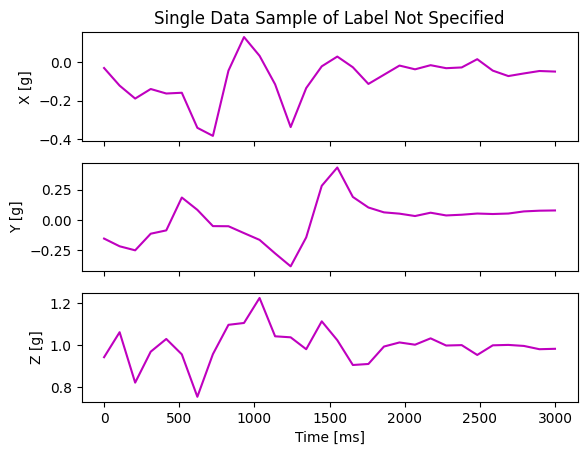

(1, 90)
Model Prediction:  [0]
Model Prediction Proba:  [[0.67765639 0.32234361]]


In [23]:
#Tarjeta horizontal, como desplazada sobre la mesa. V con el pico hacia enfrente. O en CCW
input('Press Enter once MCU is ready')
line = ser.readline()
lineList = convert_to_list(str(line))
new_df = convert_list_to_df(lineList)
print('New data acquired:\n', new_df.describe())

x = new_df['X'].to_numpy()
y = new_df['Y'].to_numpy()
z = new_df['Z'].to_numpy()

inf_data = np.array([x, y, z])
plot_single_sample(data_sample=inf_data.reshape((3, stride)))
#For inference we have to explicitly tell the model that the data has a batchsize of 1
inf_data = inf_data.reshape((1, 3, stride))
inf_data = inf_data.reshape(inf_data.shape[0], -1)
print(inf_data.shape)


pred = clf_svc.predict(inf_data)
pred_proba = clf_svc.predict_proba(inf_data)
print('Model Prediction: ', pred)
print('Model Prediction Proba: ', pred_proba)

Model Prediction Proba:  [[0.86723277 0.13276723]]


## Feature extraction

The previously trained model could performence rather poor (because we don't have much data to train with). We will now be showing the powerfull effect of feature extraction.


Instead of directly using the raw data to train, in some applications better results are achieved by first preprocessing the data into more abstract features, to _condense_ the contained information into fewer data points. This not only leads to less memory required for the features, but also to potentially smaller models and better performance. Finding good features can be very hard, but for many applications you can read papers about which features perform well and how to calculate them.

In this task a sliding window is used to calculate the piece wise mean and variance of the accelerator data.

In [5]:
data_files = [file for file in os.listdir(samples_dir) if '.csv' in file]

stride = 30
slidingWindowExt = 6
feature_data = []
feature_labels = []
for idx, file in enumerate(data_files):
    df = pd.read_csv(os.path.join(samples_dir, file))
    x = df['X'].to_numpy()
    y = df['Y'].to_numpy()
    z = df['Z'].to_numpy()
    
    for i in range(int(df.shape[0]/stride)):
        base_idx = i * stride

        # Mean feature
        x_mean_ext = np.array([np.mean(x[i:i + slidingWindowExt]) for i in range(base_idx, base_idx + stride, slidingWindowExt)])
        y_mean_ext = np.array([np.mean(y[i:i + slidingWindowExt]) for i in range(base_idx, base_idx + stride, slidingWindowExt)])
        z_mean_ext = np.array([np.mean(z[i:i + slidingWindowExt]) for i in range(base_idx, base_idx + stride, slidingWindowExt)])
        # STD feature
        x_std_ext = np.array([np.std(x[i:i + slidingWindowExt]) for i in range(base_idx, base_idx + stride, slidingWindowExt)])
        y_std_ext = np.array([np.std(y[i:i + slidingWindowExt]) for i in range(base_idx, base_idx + stride, slidingWindowExt)])
        z_std_ext = np.array([np.std(z[i:i + slidingWindowExt]) for i in range(base_idx, base_idx + stride, slidingWindowExt)])
        
        batch = np.array([x_mean_ext, y_mean_ext, z_mean_ext, x_std_ext, y_std_ext, z_std_ext])
        feature_data.append(batch)
        feature_labels.append(idx)
        
    print('Added {} data to the feature data list with label: {}'.format(file, idx))

print(feature_data[0].shape)
print(feature_data)

Added letter_L_stride_30.csv data to the feature data list with label: 0
Added letter_o_stride_30.csv data to the feature data list with label: 1
Added letter_v_stride_30.csv data to the feature data list with label: 2
(6, 5)
[array([[ -916.        , -1073.66666667, -1050.5       ,  -988.5       ,
         -998.33333333],
       [  -87.66666667,  -257.        ,    69.16666667,  -154.66666667,
         -149.66666667],
       [   97.83333333,  -148.66666667,   -75.83333333,   -48.33333333,
          -41.16666667],
       [  161.03829772,   513.18601782,   127.32471611,    18.83038325,
           25.82419193],
       [   30.32417444,   287.13817812,   311.86985355,    41.45144415,
           23.3428552 ],
       [   52.44494468,    77.6845473 ,    89.00827053,    15.36952251,
            9.22707369]]), array([[ -832.33333333, -1246.16666667, -1054.5       ,  -977.33333333,
        -1001.33333333],
       [  -49.16666667,  -185.66666667,   -18.66666667,  -102.        ,
         -128.166666

<Figure size 640x480 with 0 Axes>

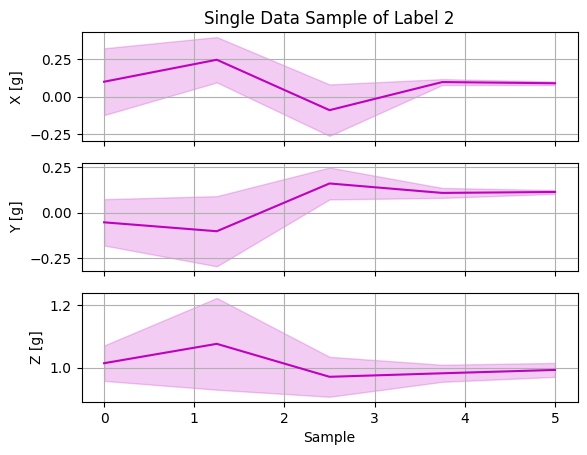

In [3]:
def plot_single_feature_sample(data_sample, label='Not Specified'):
    plt.clf()
    fig, axs = plt.subplots(3)
    t = np.linspace(0, data_sample.shape[1], data_sample.shape[1])
    scaling = 2**10 #The STM ADC is 10bit so scale to get [g]
    axs[0].set_title(label='Single Data Sample of Label {}'.format(feature_labels[idx]))
    
    xf_means = data_sample[0] / scaling
    yf_means = data_sample[1] / scaling
    zf_means = data_sample[2] / scaling
    
    xf_stds = data_sample[3] / scaling
    yf_stds = data_sample[4] / scaling
    zf_stds = data_sample[5] / scaling
    
    axs[0].grid()
    axs[0].plot(t, xf_means, c='m')
    axs[0].fill_between(t, xf_means - xf_stds, xf_means + xf_stds, alpha=0.2, color='m')
    axs[0].set_ylabel('X [g]')
    plt.setp(axs[0].get_xticklabels(), visible=False)
    axs[1].grid()
    axs[1].plot(t, yf_means, c='m')
    axs[1].fill_between(t, yf_means - yf_stds, yf_means + yf_stds, alpha=0.2, color='m')
    axs[1].set_ylabel('Y [g]')
    plt.setp(axs[1].get_xticklabels(), visible=False)
    axs[2].grid()
    axs[2].plot(t, zf_means, c='m')
    axs[2].fill_between(t, zf_means - zf_stds, zf_means + zf_stds, alpha=0.2, color='m')
    axs[2].set_ylabel('Z [g]')
    
    plt.xlabel('Sample')
    plt.show()
    
idx = random.randint(0, len(feature_data)-1)
plot_single_feature_sample(data_sample=feature_data[idx], label=feature_labels[idx])

In [ ]:
# Complete the new feature data set separation

In [ ]:
#Complete for model training

In [ ]:
#Complete for inference